# 01 — Vendor Uncertainty Distributions

**Purpose**: Fit probability distributions to the vendor-level dispersion in physical damage ratio estimates from the CFRF/GARP benchmarking study.

**Input**: Summary statistics (min, mean, max across 13 vendors) for 100 properties, defended combined flooding at RP200 in 2030.

**Output**: Fitted Triangular (primary), Uniform (robustness), and Beta (comparison) distributions for each property; diagnostic plots; saved fit results for downstream notebooks.

**Key design choices**:
- Damage ratios bounded on [0, 1]
- **Primary distribution: Triangular** — moment-matched via mode = 3·mean − min − max; no free parameters; fully determined by observed summary statistics
- Uniform as maximum-entropy robustness check; Beta retained for comparison
- Zero-damage properties flagged and excluded from fitting (re-added at portfolio stage)

This notebook is **shared infrastructure** — used by all four stylised financial decisions.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import yaml
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path(".").resolve().parent.parent / "src"))

from uncertainty.distributions import (
    fit_beta_quantile_matching,
    fit_triangular_from_moments,
    fit_uniform,
    fit_all_distributions,
)
from utils.plotting import set_style, COLOURS

set_style()

# Load config
with open("../../config/parameters.yaml", "r") as f:
    config = yaml.safe_load(f)

print("Config loaded. Scenario:", config["data"]["scenario"])

Config loaded. Scenario: RP200_2030_defended_combined


## 1. Load and inspect raw data

In [2]:
df = pd.read_csv("../../data/raw/cfrf_garp_defended_flood.csv")

# Clean: drop empty trailing columns and rows
df = df.dropna(axis=1, how="all")
df = df.dropna(subset=["property_rank"])
# Fix typo in column name
df = df.rename(columns={"minimim_dr": "minimum_dr"})
df["property_rank"] = df["property_rank"].astype(int)

print(f"Properties: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Categorise properties by damage profile
zero_mask = (df.minimum_dr == 0) & (df.mean_dr == 0) & (df.maximum_dr == 0)
near_zero_mask = (df.mean_dr == 0) & (df.maximum_dr > 0) & ~zero_mask
has_uncertainty = ~zero_mask & ~near_zero_mask

print(f"\nZero-damage (all vendors = 0):      {zero_mask.sum()}")
print(f"Near-zero (mean=0, max=0.01):        {near_zero_mask.sum()}")
print(f"Properties with vendor uncertainty:   {has_uncertainty.sum()}")

df.head(10)

Properties: 100
Columns: ['property_rank', 'minimum_m', 'mean_m', 'maximum_m', 'minimum_dr', 'mean_dr', 'maximum_dr']

Zero-damage (all vendors = 0):      20
Near-zero (mean=0, max=0.01):        5
Properties with vendor uncertainty:   75


,property_rank,minimum_m,mean_m,maximum_m,minimum_dr,mean_dr,maximum_dr
0,1,2.5,5.6,9.5,0.00,0.59,1.00
1,2,0.0,3.6,7.5,0.25,0.50,1.00
2,3,1.6,3.5,6.5,0.00,0.36,0.57
3,4,0.0,3.0,9.8,0.00,0.31,0.79
4,5,0.0,3.0,6.2,0.00,0.35,1.00
5,6,1.5,2.6,6.0,0.22,0.61,1.00
6,7,1.1,2.5,6.3,0.16,0.38,0.72
7,8,0.7,2.4,6.0,0.00,0.38,1.00
8,9,0.5,2.4,4.8,0.00,0.26,0.68
9,10,0.6,2.3,6.0,0.11,0.39,1.00


In [3]:
# Summary statistics of the damage ratio columns
print("=== Damage ratio summary across 100 properties ===")
print(f"Mean DR — median: {df.mean_dr.median():.3f}, range: [{df.mean_dr.min():.3f}, {df.mean_dr.max():.3f}]")
print(f"Min DR  — fraction that are zero: {(df.minimum_dr == 0).mean():.1%}")
print(f"Max DR  — fraction that are zero: {(df.maximum_dr == 0).mean():.1%}")
print(f"Vendor spread (max-min) — median: {(df.maximum_dr - df.minimum_dr).median():.3f}")

# Identify zero-damage properties
zero_mask = (df.minimum_dr == 0) & (df.mean_dr == 0) & (df.maximum_dr == 0)
print(f"\nZero-damage properties (all vendors agree = 0): {zero_mask.sum()}")
print(f"Properties with vendor uncertainty: {(~zero_mask).sum()}")

=== Damage ratio summary across 100 properties ===
Mean DR — median: 0.080, range: [0.000, 0.610]
Min DR  — fraction that are zero: 95.0%
Max DR  — fraction that are zero: 20.0%
Vendor spread (max-min) — median: 0.250

Zero-damage properties (all vendors agree = 0): 20
Properties with vendor uncertainty: 80


FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/figures/shared/raw_vendor_dispersion.png'

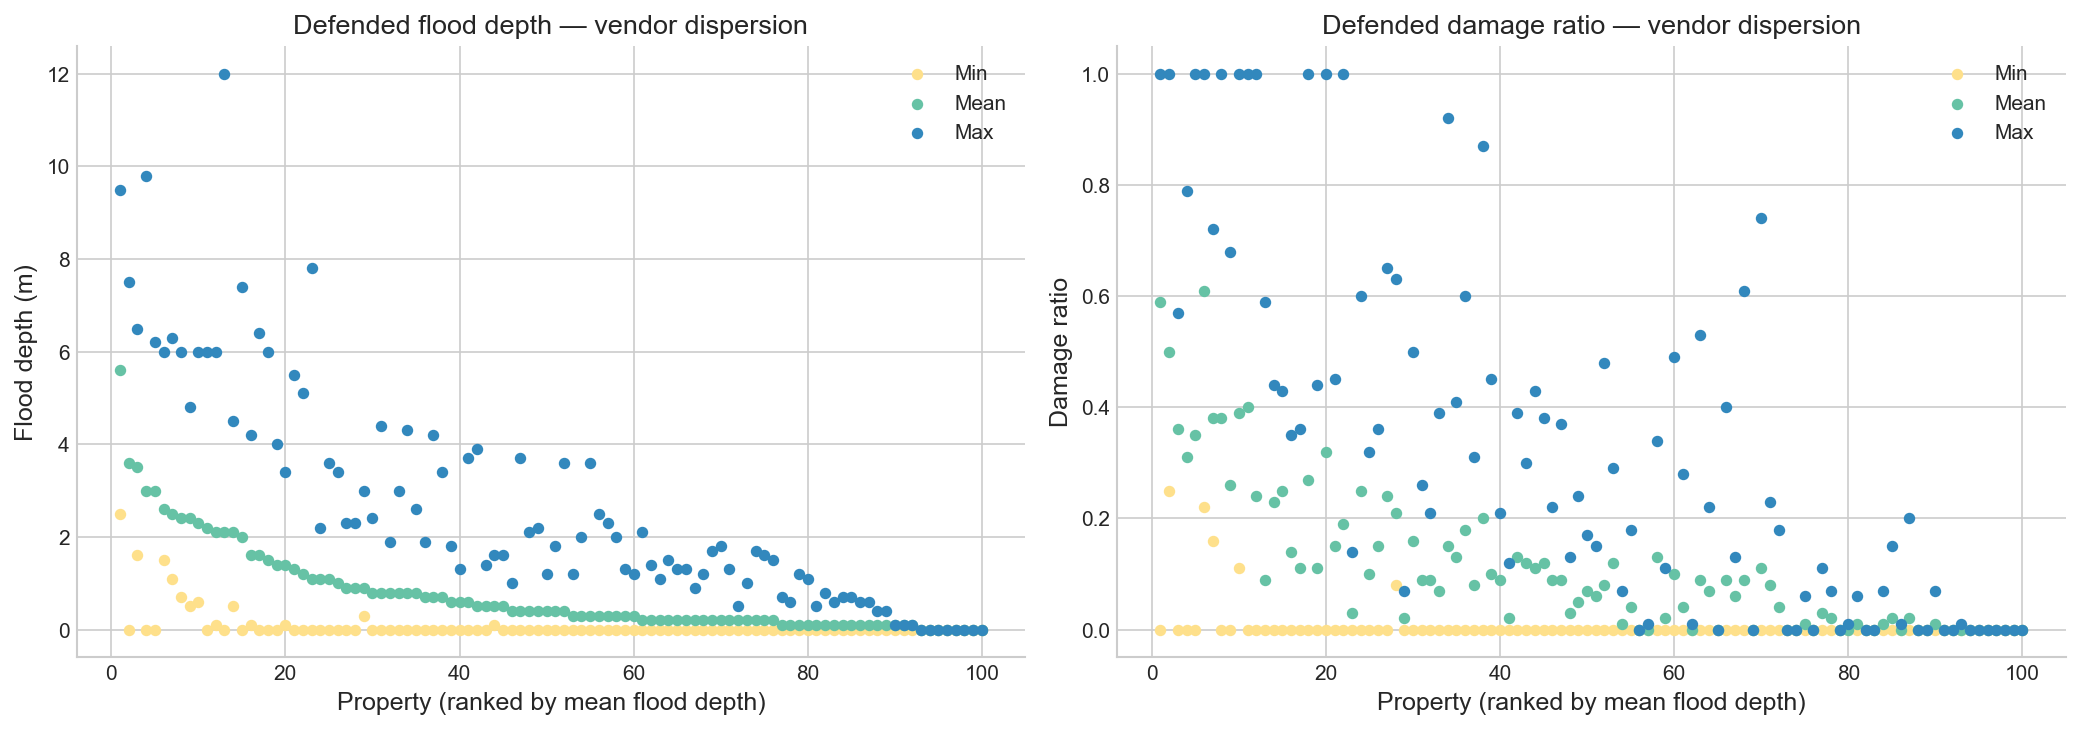

In [4]:
# Reproduce Figure 19/20 style visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flood depth
ax = axes[0]
ax.scatter(df.property_rank, df.minimum_m, c=COLOURS["data_min"], s=20, label="Min", zorder=3)
ax.scatter(df.property_rank, df.mean_m, c=COLOURS["data_mean"], s=20, label="Mean", zorder=3)
ax.scatter(df.property_rank, df.maximum_m, c=COLOURS["data_max"], s=20, label="Max", zorder=3)
ax.set_xlabel("Property (ranked by mean flood depth)")
ax.set_ylabel("Flood depth (m)")
ax.set_title("Defended flood depth — vendor dispersion")
ax.legend()

# Damage ratio
ax = axes[1]
ax.scatter(df.property_rank, df.minimum_dr, c=COLOURS["data_min"], s=20, label="Min", zorder=3)
ax.scatter(df.property_rank, df.mean_dr, c=COLOURS["data_mean"], s=20, label="Mean", zorder=3)
ax.scatter(df.property_rank, df.maximum_dr, c=COLOURS["data_max"], s=20, label="Max", zorder=3)
ax.set_xlabel("Property (ranked by mean flood depth)")
ax.set_ylabel("Damage ratio")
ax.set_title("Defended damage ratio — vendor dispersion")
ax.legend()

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/raw_vendor_dispersion.png")
plt.show()

## 2. Fit distributions — all three families

Fit Triangular (primary), Uniform (robustness check), and Beta (comparison) to all properties using the order statistic interpretation of min/max.

In [5]:
# Fit all three distributions — order statistic interpretation
qi = config["distribution_fitting"]["quantile_interpretations"]["order_statistic"]
print(f"Quantile interpretation: order_statistic")
print(f"  Lower quantile: {qi['lower_quantile']}")
print(f"  Upper quantile: {qi['upper_quantile']}")

fit_os = fit_all_distributions(
    df,
    beta_lower_q=qi["lower_quantile"],
    beta_upper_q=qi["upper_quantile"],
    beta_interpretation="order_statistic",
)

# Summary
n_beta_ok = fit_os.beta_success.sum()
n_tri_ok = fit_os.tri_success.sum()
n_uni_ok = fit_os.uni_success.sum()
print(f"\nSuccessful fits (out of {len(fit_os)}):")
print(f"  Beta:       {n_beta_ok}")
print(f"  Triangular: {n_tri_ok}")
print(f"  Uniform:    {n_uni_ok}")

# Properties where triangular mode was clamped
n_clamped = fit_os.tri_clamped.sum()
print(f"  Triangular mode clamped: {n_clamped}")

Quantile interpretation: order_statistic
  Lower quantile: 0.0538
  Upper quantile: 0.9462

Successful fits (out of 100):
  Beta:       75
  Triangular: 80
  Uniform:    80
  Triangular mode clamped: 52


## 3. Diagnostic plots — representative properties

Select a few properties spanning the range of vendor uncertainty to inspect fitted distributions visually.

In [7]:
def plot_property_distributions(prop_idx, df, fit_results, title_suffix=""):
    """Plot fitted Beta, Triangular, and Uniform PDFs for a single property."""
    row = df.iloc[prop_idx]
    d_min, d_mean, d_max = row.minimum_dr, row.mean_dr, row.maximum_dr
    prop_rank = int(row.property_rank)

    if d_max == 0 and d_mean == 0:
        print(f"Property {prop_rank}: zero damage, skipping")
        return

    fig, ax = plt.subplots(figsize=(8, 4.5))

    # x grid for PDFs
    x_lo = max(0, d_min - 0.05)
    x_hi = min(1, d_max + 0.05)
    x = np.linspace(x_lo, x_hi, 500)

    # Fit each distribution for this property
    qi = config["distribution_fitting"]["quantile_interpretations"]["order_statistic"]
    beta_fit = fit_beta_quantile_matching(d_min, d_mean, d_max,
                                          lower_q=qi["lower_quantile"],
                                          upper_q=qi["upper_quantile"],
                                          interpretation="order_statistic")
    tri_fit = fit_triangular_from_moments(d_min, d_mean, d_max)
    uni_fit = fit_uniform(d_min, d_mean, d_max)

    # Plot PDFs
    # if beta_fit.fit_success and beta_fit.scipy_dist is not None:
    #     ax.plot(x, beta_fit.scipy_dist.pdf(x), color=COLOURS["beta"],
    #             lw=2, label=f"Beta (a={beta_fit.params['a']:.2f}, b={beta_fit.params['b']:.2f})")
    if tri_fit.fit_success and tri_fit.scipy_dist is not None:
        ax.plot(x, tri_fit.scipy_dist.pdf(x), color=COLOURS["triangular"],
                lw=2, ls="--", label=f"Triangular (mode={tri_fit.params['mode']:.3f})")
    # if uni_fit.fit_success and uni_fit.scipy_dist is not None:
    #     ax.plot(x, uni_fit.scipy_dist.pdf(x), color=COLOURS["uniform"],
    #             lw=2, ls=":", label=f"Uniform [{d_min:.2f}, {d_max:.2f}]")

    # Mark empirical summary stats
    for val, label, color in [(d_min, "Min", COLOURS["data_min"]),
                               (d_mean, "Mean", COLOURS["data_mean"]),
                               (d_max, "Max", COLOURS["data_max"])]:
        ax.axvline(val, color=color, lw=1.5, alpha=0.7, label=f"Vendor {label}: {val:.3f}")

    ax.set_xlabel("Damage ratio")
    ax.set_ylabel("Probability density")
    ax.set_title(f"Property {prop_rank} — Fitted vendor uncertainty distributions{title_suffix}")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    return fig

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/figures/shared/dist_fit_property_1.png'

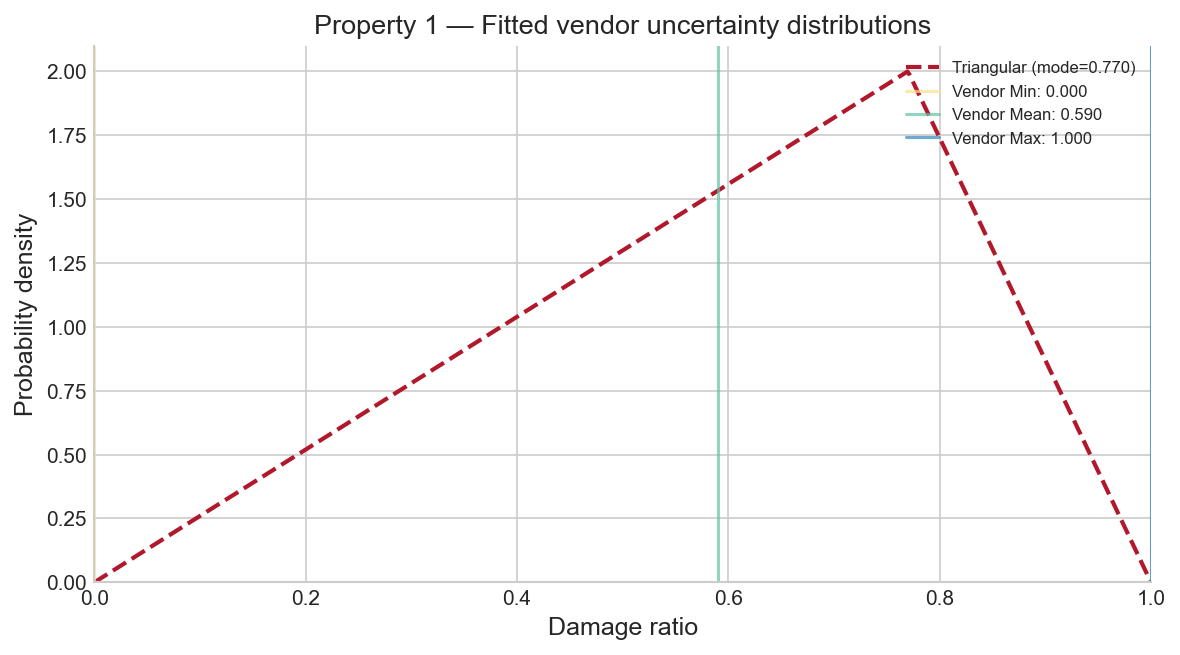

In [8]:
# Select representative properties
# High uncertainty (top of ranking, large spread)
# Moderate uncertainty (mid-ranking)
# Low uncertainty (bottom, small spread)
representative = [0, 5, 15, 30, 50, 70]  # indices into df

for idx in representative:
    fig = plot_property_distributions(idx, df, fit_os)
    if fig is not None:
        plt.savefig(f"../../outputs/figures/shared/dist_fit_property_{int(df.iloc[idx].property_rank)}.png")
        plt.show()

## 4. Beta sensitivity to quantile interpretation (robustness)

The Beta fit is sensitive to the assumed quantile levels for min/max. This section shows how results change across the three interpretations — useful context for why we prefer the parameter-free Triangular as primary.

In [22]:
interpretations = {
    "order_statistic": config["distribution_fitting"]["quantile_interpretations"]["order_statistic"],
    "quantile_approx": config["distribution_fitting"]["quantile_interpretations"]["quantile_approx"],
    "extremes": config["distribution_fitting"]["quantile_interpretations"]["extremes"],
}

fit_results_by_interp = {}

for interp_name, qi in interpretations.items():
    if interp_name == "extremes":
        fit_results_by_interp[interp_name] = fit_all_distributions(
            df, beta_interpretation="extremes",
        )
    else:
        fit_results_by_interp[interp_name] = fit_all_distributions(
            df,
            beta_lower_q=qi["lower_quantile"],
            beta_upper_q=qi["upper_quantile"],
            beta_interpretation=interp_name,
        )
    n_ok = fit_results_by_interp[interp_name].beta_success.sum()
    print(f"{interp_name}: {n_ok} successful Beta fits")

order_statistic: 75 successful Beta fits
quantile_approx: 75 successful Beta fits
extremes: 75 successful Beta fits


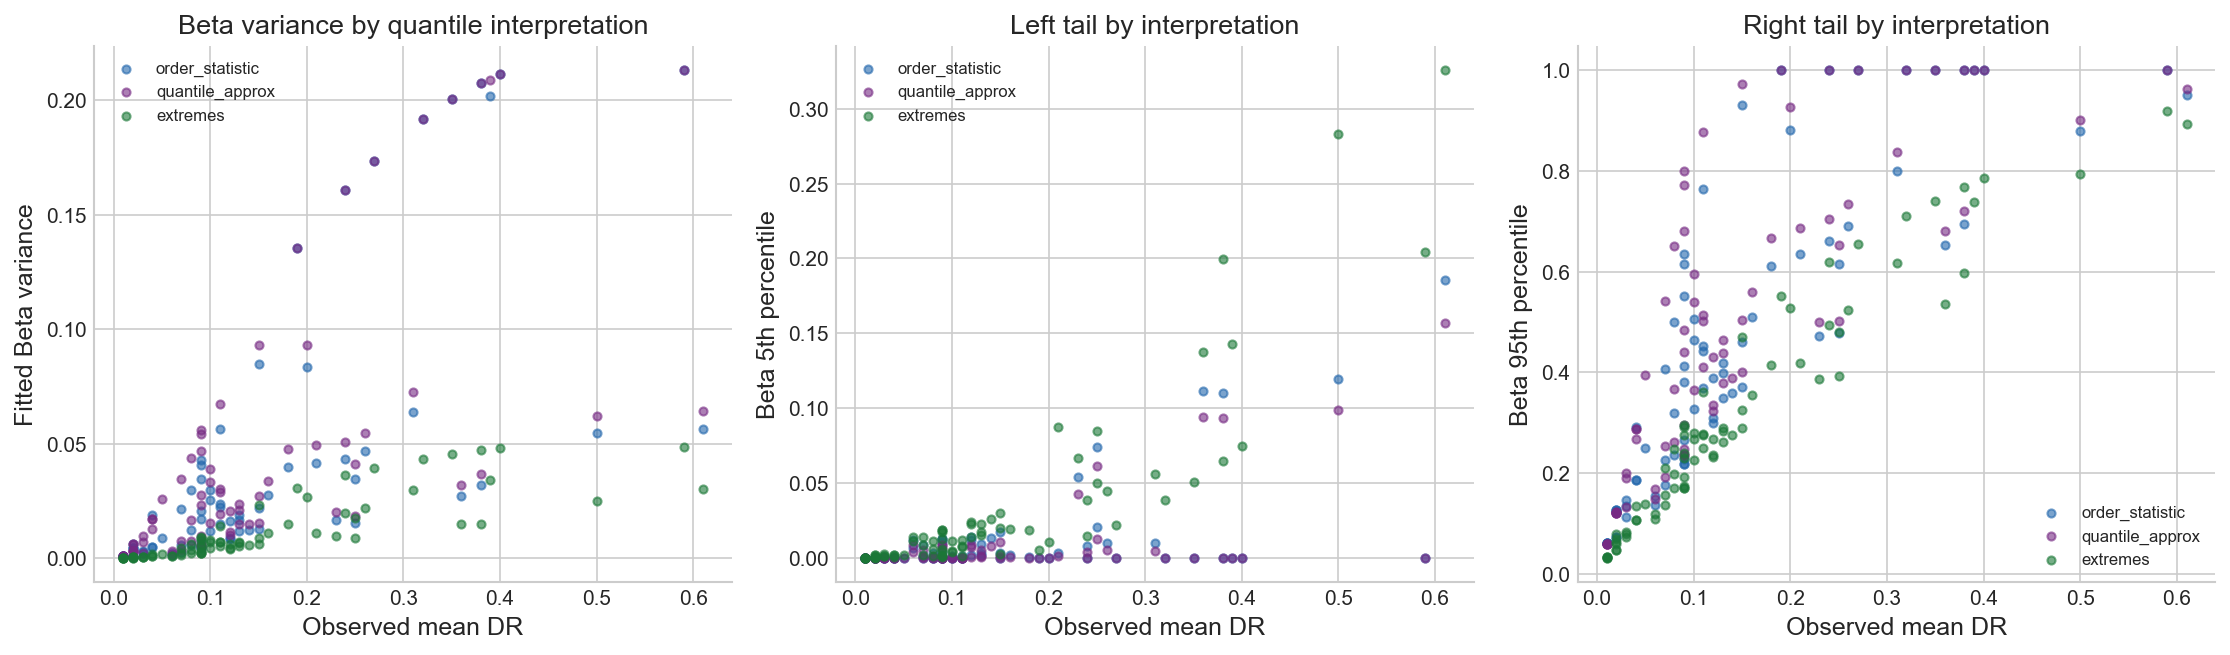

In [23]:
# Compare Beta variance across interpretations for non-zero properties
non_zero = ~fit_os.is_zero_damage

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Beta variance by interpretation
ax = axes[0]
for interp_name, color in [("order_statistic", "#2166ac"), ("quantile_approx", "#762a83"), ("extremes", "#1b7837")]:
    fr = fit_results_by_interp[interp_name]
    mask = non_zero & fr.beta_success
    ax.scatter(fr.loc[mask, "d_mean"], fr.loc[mask, "beta_var"],
               s=15, alpha=0.6, label=interp_name, color=color)
ax.set_xlabel("Observed mean DR")
ax.set_ylabel("Fitted Beta variance")
ax.set_title("Beta variance by quantile interpretation")
ax.legend(fontsize=8)

# Panel 2: Beta 5th percentile
ax = axes[1]
for interp_name, color in [("order_statistic", "#2166ac"), ("quantile_approx", "#762a83"), ("extremes", "#1b7837")]:
    fr = fit_results_by_interp[interp_name]
    mask = non_zero & fr.beta_success
    ax.scatter(fr.loc[mask, "d_mean"], fr.loc[mask, "beta_q05"],
               s=15, alpha=0.6, label=interp_name, color=color)
ax.set_xlabel("Observed mean DR")
ax.set_ylabel("Beta 5th percentile")
ax.set_title("Left tail by interpretation")
ax.legend(fontsize=8)

# Panel 3: Beta 95th percentile
ax = axes[2]
for interp_name, color in [("order_statistic", "#2166ac"), ("quantile_approx", "#762a83"), ("extremes", "#1b7837")]:
    fr = fit_results_by_interp[interp_name]
    mask = non_zero & fr.beta_success
    ax.scatter(fr.loc[mask, "d_mean"], fr.loc[mask, "beta_q95"],
               s=15, alpha=0.6, label=interp_name, color=color)
ax.set_xlabel("Observed mean DR")
ax.set_ylabel("Beta 95th percentile")
ax.set_title("Right tail by interpretation")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/beta_quantile_interpretation_comparison.png")
plt.show()

## 5. Cross-distribution comparison

Compare Triangular (primary) vs. Beta vs. Uniform in terms of fitted variance and tail quantiles across all properties.

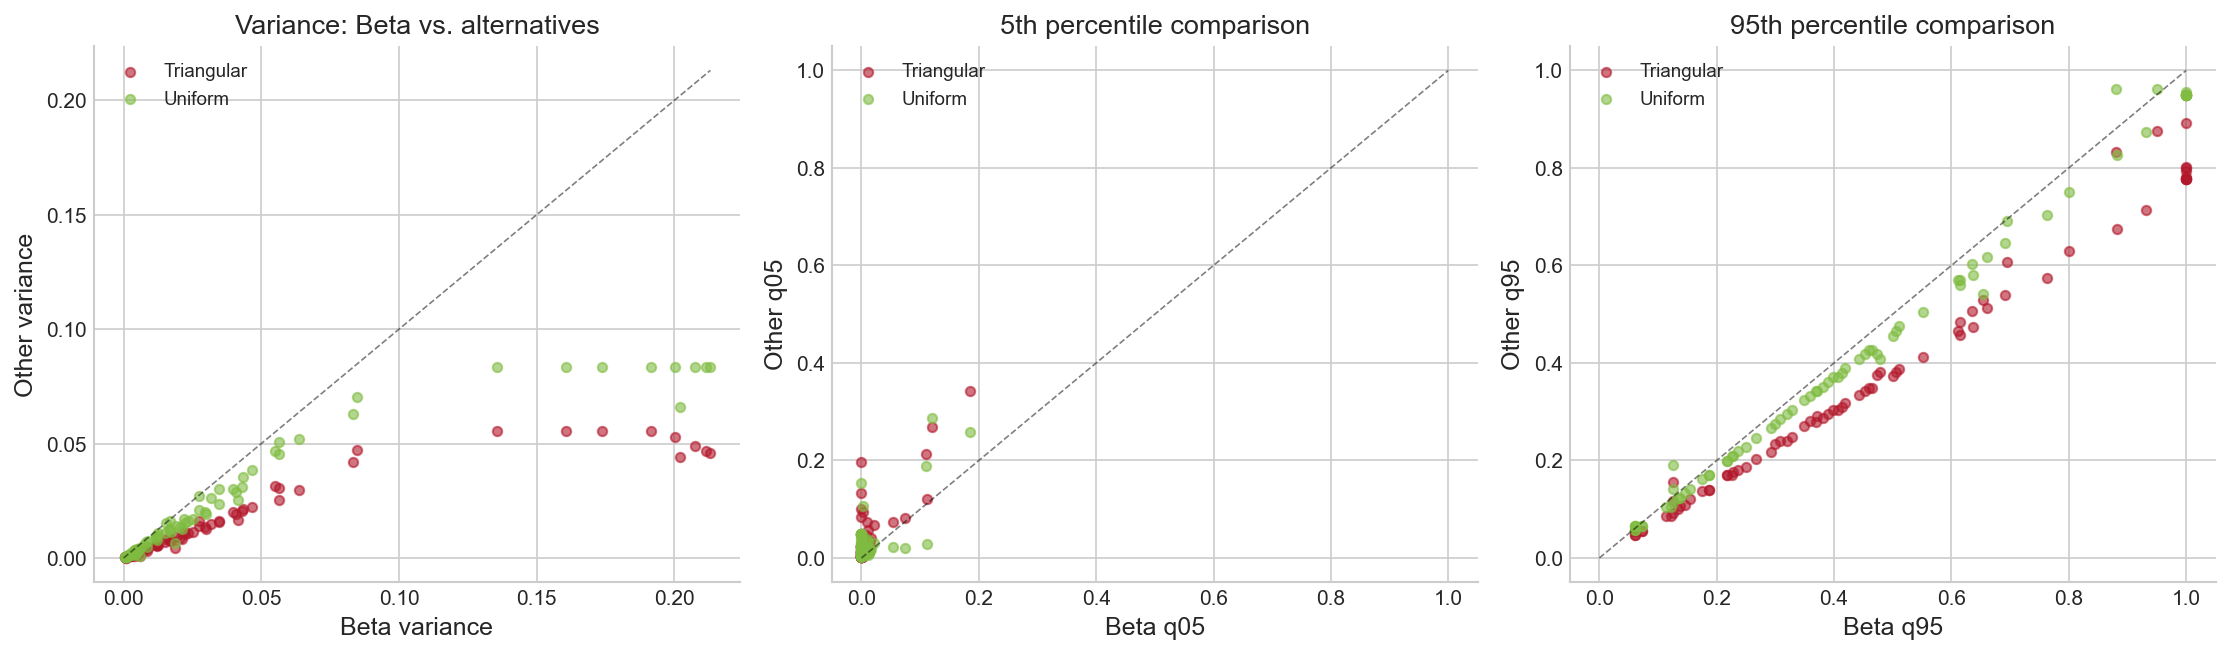

In [24]:
# Use order_statistic as the reference Beta fit
fr = fit_os.copy()
non_zero = ~fr.is_zero_damage
valid = non_zero & fr.beta_success & fr.tri_success & fr.uni_success

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Variance comparison
ax = axes[0]
ax.scatter(fr.loc[valid, "beta_var"], fr.loc[valid, "tri_var"],
           s=20, alpha=0.6, color=COLOURS["triangular"], label="Triangular")
ax.scatter(fr.loc[valid, "beta_var"], fr.loc[valid, "uni_var"],
           s=20, alpha=0.6, color=COLOURS["uniform"], label="Uniform")
lim = max(fr.loc[valid, ["beta_var", "tri_var", "uni_var"]].max().max(), 0.01)
ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("Beta variance")
ax.set_ylabel("Other variance")
ax.set_title("Variance: Beta vs. alternatives")
ax.legend(fontsize=9)

# 5th percentile
ax = axes[1]
ax.scatter(fr.loc[valid, "beta_q05"], fr.loc[valid, "tri_q05"],
           s=20, alpha=0.6, color=COLOURS["triangular"], label="Triangular")
ax.scatter(fr.loc[valid, "beta_q05"], fr.loc[valid, "uni_q05"],
           s=20, alpha=0.6, color=COLOURS["uniform"], label="Uniform")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("Beta q05")
ax.set_ylabel("Other q05")
ax.set_title("5th percentile comparison")
ax.legend(fontsize=9)

# 95th percentile
ax = axes[2]
ax.scatter(fr.loc[valid, "beta_q95"], fr.loc[valid, "tri_q95"],
           s=20, alpha=0.6, color=COLOURS["triangular"], label="Triangular")
ax.scatter(fr.loc[valid, "beta_q95"], fr.loc[valid, "uni_q95"],
           s=20, alpha=0.6, color=COLOURS["uniform"], label="Uniform")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("Beta q95")
ax.set_ylabel("Other q95")
ax.set_title("95th percentile comparison")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/distribution_comparison.png")
plt.show()

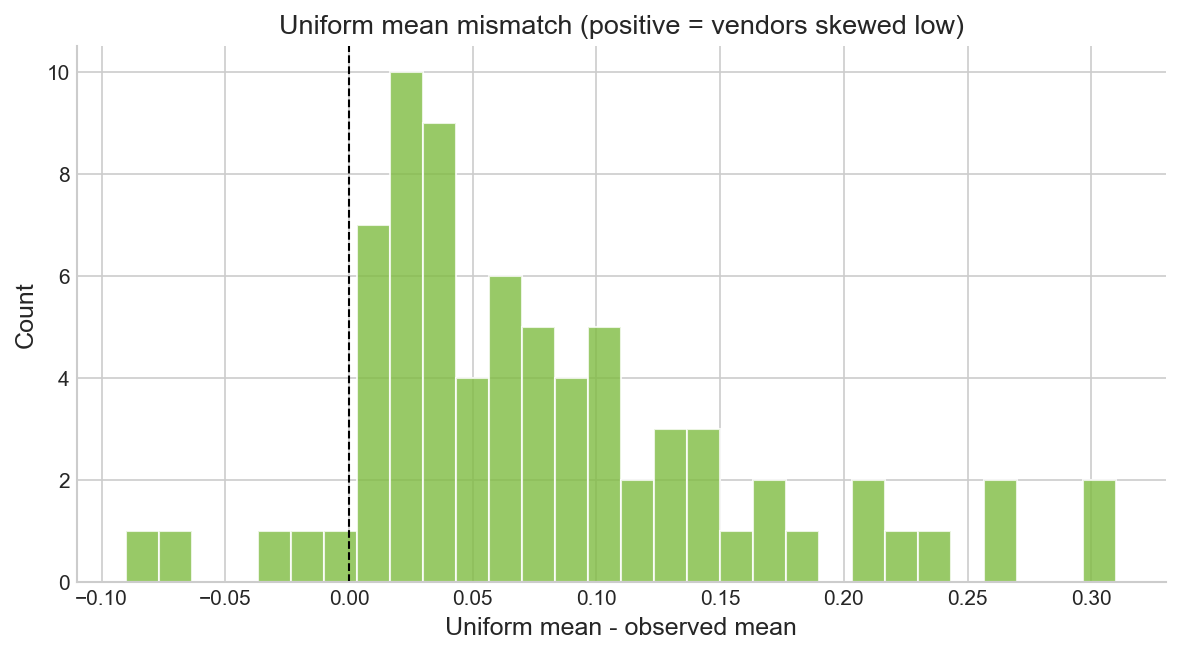

Median mismatch: 0.0650
Properties with |mismatch| > 0.05: 43


In [25]:
# Uniform mean mismatch — shows asymmetry of vendor distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
mismatch = fr.loc[valid, "uni_mean_mismatch"]
ax.hist(mismatch, bins=30, color=COLOURS["uniform"], edgecolor="white", alpha=0.8)
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("Uniform mean - observed mean")
ax.set_ylabel("Count")
ax.set_title("Uniform mean mismatch (positive = vendors skewed low)")
plt.tight_layout()
plt.savefig("../../outputs/figures/shared/uniform_mean_mismatch.png")
plt.show()

print(f"Median mismatch: {mismatch.median():.4f}")
print(f"Properties with |mismatch| > 0.05: {(mismatch.abs() > 0.05).sum()}")

## 6. Summary table and save results

In [26]:
# Build a compact summary table — triangular columns first as primary distribution
summary = fr.loc[non_zero, [
    "property_rank", "d_min", "d_mean", "d_max",
    "tri_mode", "tri_clamped", "tri_var", "tri_success",
    "uni_var", "uni_mean_mismatch",
    "beta_a", "beta_b", "beta_var", "beta_success",
]].copy()

summary["vendor_spread"] = summary["d_max"] - summary["d_min"]

print(f"Properties with vendor uncertainty: {len(summary)}")
print(f"\nMedian vendor spread: {summary.vendor_spread.median():.3f}")
print(f"Max vendor spread: {summary.vendor_spread.max():.3f}")
print(f"\nTriangular mode clamped: {summary.tri_clamped.sum()}")
print(f"Beta fit failures:       {(~summary.beta_success).sum()}")

summary.head(15)

Properties with vendor uncertainty: 80

Median vendor spread: 0.365
Max vendor spread: 1.000

Triangular mode clamped: 52
Beta fit failures:       5


,property_rank,d_min,d_mean,d_max,tri_mode,tri_clamped,tri_var,tri_success,uni_var,uni_mean_mismatch,beta_a,beta_b,beta_var,beta_success,vendor_spread
0,1.0,0.00,0.59,1.00,0.77,False,0.045717,True,0.083333,-0.090,0.079848,0.055488,0.213065,True,1.00
1,2.0,0.25,0.50,1.00,0.25,False,0.031250,True,0.046875,0.125,1.780313,1.780313,0.054817,True,0.75
2,3.0,0.00,0.36,0.57,0.51,False,0.016350,True,0.027075,-0.075,2.669263,4.745357,0.027381,True,0.57
3,4.0,0.00,0.31,0.79,0.14,False,0.029617,True,0.052008,0.085,0.728420,1.621321,0.063856,True,0.79
4,5.0,0.00,0.35,1.00,0.05,False,0.052917,True,0.083333,0.150,0.047368,0.087968,0.200381,True,1.00
5,6.0,0.22,0.61,1.00,0.61,False,0.025350,True,0.050700,0.000,1.959422,1.252745,0.056479,True,0.78
6,7.0,0.16,0.38,0.72,0.26,False,0.014867,True,0.026133,0.060,2.435880,3.974330,0.031794,True,0.56
7,8.0,0.00,0.38,1.00,0.14,False,0.048867,True,0.083333,0.120,0.051428,0.083908,0.207516,True,1.00
8,9.0,0.00,0.26,0.68,0.10,False,0.022467,True,0.038533,0.080,0.808835,2.302070,0.046802,True,0.68
9,10.0,0.11,0.39,1.00,0.11,True,0.044006,True,0.066008,0.165,0.069366,0.108496,0.201976,True,0.89


In [27]:
# Save full fit results for downstream notebooks
# Triangular is the primary distribution; saved as the default
fit_os.to_csv("../../data/processed/fitted_distributions_triangular.csv", index=False)

# Also save extremes interpretation (Beta) for robustness comparison
fit_results_by_interp["extremes"].to_csv(
    "../../data/processed/fitted_distributions_beta_extremes.csv", index=False
)

# Save clean data with column name fix
df.to_csv("../../data/processed/cfrf_garp_clean.csv", index=False)

print("Saved:")
print("  data/processed/fitted_distributions_triangular.csv  (primary)")
print("  data/processed/fitted_distributions_beta_extremes.csv  (robustness)")
print("  data/processed/cfrf_garp_clean.csv")

Saved:
  data/processed/fitted_distributions_triangular.csv  (primary)
  data/processed/fitted_distributions_beta_extremes.csv  (robustness)
  data/processed/cfrf_garp_clean.csv


## 7. Notes for downstream notebooks

**Distribution choice for simulation**: The **Triangular** distribution is the primary choice for all downstream simulation. It exactly matches all three observed summary statistics (min, mean, max) via moment-matching (mode = 3·mean − min − max), is fully transparent, and has no free parameters requiring optimisation. The Uniform serves as the maximum-entropy robustness check (most dispersed). Beta is retained for comparison only.

**Triangular mode clamping**: 52 of 80 properties have an implied mode outside [min, max] — occurring where the vendor distribution is highly right-skewed (mean close to min). In these cases the mode is clamped to the nearest boundary, producing a right-triangle shape. This is the correct representation: the triangular family cannot simultaneously honour a skewed mean and a smooth interior peak. The clamping rate is noted as a limitation in the paper.

**Zero-damage properties**: 20 properties have zero damage across all vendors. These carry no vendor uncertainty and are re-added at the portfolio construction stage (Notebook 02) as point masses at d=0.

**Uniform mean mismatch**: The Uniform assumes symmetric spread and does not match the observed mean. This is deliberate — it represents maximum ignorance about shape. The mismatch quantifies the asymmetry in vendor distributions (typically right-skewed: most vendors report low damage, a few report high).

**Next step**: Notebook 02 constructs the stylised loan portfolio by assigning loan characteristics (EAD, maturity, baseline PD/LGD) to each property.